,image_path,h11,h12,h13,h21,h22,h23,h31,h32
0,peper/input_images\1.png,1.550024,0.085322,-76.249814,-0.200061,2.200670,-118.436065,-0.000760,0.001391
1,peper/input_images\1frame_0000.png,1.756865,0.111463,-288.996300,0.079723,2.642253,-698.784706,0.000056,0.000388
2,peper/input_images\1frame_0001.jpg,1.782410,0.115527,-295.913089,0.046910,2.685599,-753.539157,0.000049,0.000381
3,peper/input_images\1frame_0002.jpg,1.702126,0.072652,-254.426312,0.032984,2.484775,-556.237677,0.000002,0.000310
4,peper/input_images\1frame_0003.jpg,1.784545,0.088949,-279.211813,0.046527,2.558977,-646.444046,0.000023,0.000314


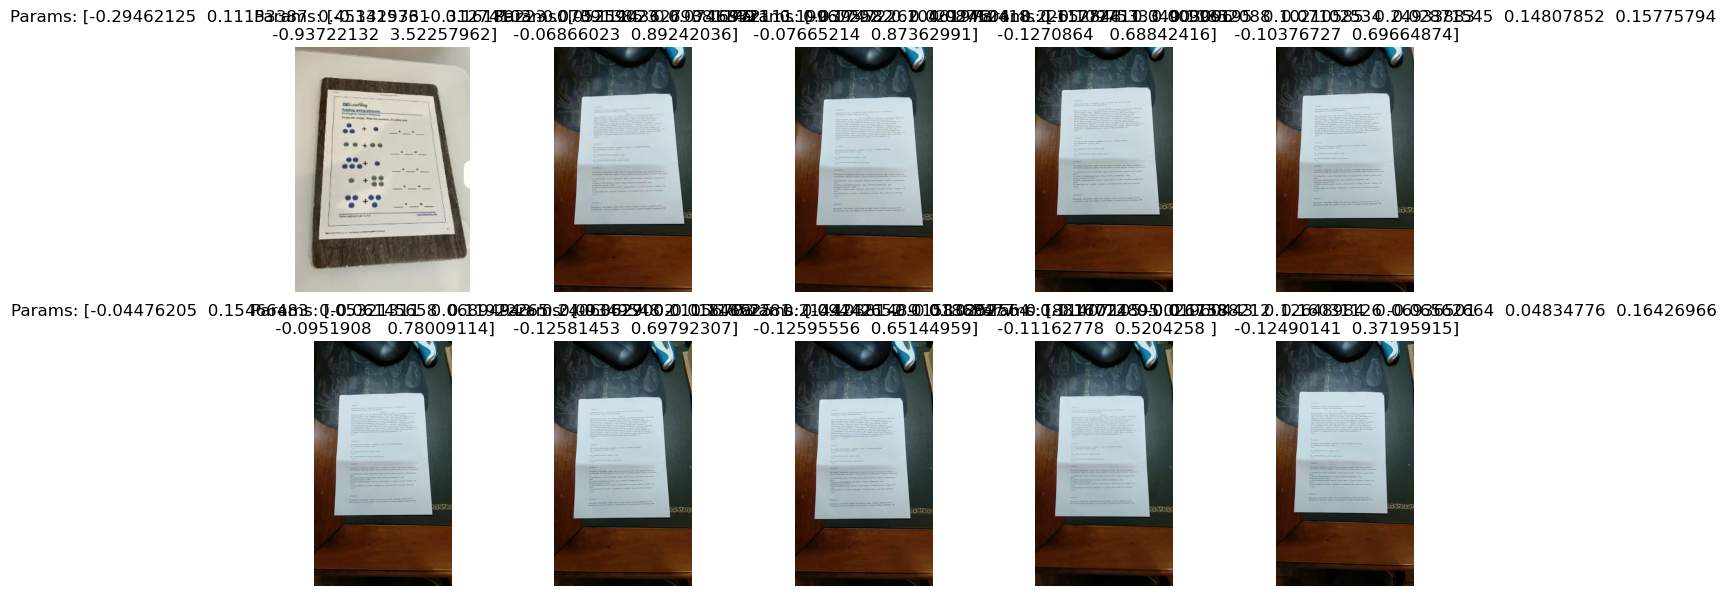

H before augmentation: [[ 0.48726496  0.37564275 -0.45510802]
 [-0.30005944  0.67845953 -1.12229824]
 [-0.17442369  0.60604328  1.        ]]
H after augmentation: [[ 0.48909314  0.37148139 -0.44822748]
 [-0.29707021  0.68074692 -1.1250639 ]
 [-0.17442369  0.60604328  1.        ]]
H before augmentation: [[-0.15009198 -0.65647608  0.02697167]
 [ 0.18945737 -0.64055151  0.52346957]
 [ 0.08655073 -0.53361392  1.        ]]
H after augmentation: [[-0.1549139  -0.63978843  0.0135027 ]
 [ 0.18553539 -0.65721979  0.52399002]
 [ 0.08655073 -0.53361392  1.        ]]
H before augmentation: [[-0.44241375 -0.06823201  0.33596349]
 [-0.22094022 -0.46922049  0.7517553 ]
 [-0.14042242 -0.72421938  1.        ]]
H after augmentation: [[-0.43285824 -0.04869003  0.30445909]
 [-0.23911973 -0.47164898  0.76505696]
 [-0.14042242 -0.72421938  1.        ]]
H before augmentation: [[-0.22468905  0.00748752  0.22182465]
 [-0.06124092 -0.15233094  0.20556888]
 [-0.09136202 -0.08520529  1.        ]]
H after augmenta

RuntimeError: The size of tensor a (8) must match the size of tensor b (6) at non-singleton dimension 1

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import math

# Пути к данным
PATH = 'peper/'
TRAIN_PATH = PATH + 'homography_data.csv'

# Загрузка данных
train_df = pd.read_csv(TRAIN_PATH)
display(train_df.head())

# Нормализация параметров гомографии
scaler = StandardScaler()
train_labels = scaler.fit_transform(train_df.iloc[:, 1:].values)  # Нормализуем параметры

# Преобразование данных
train_images = []
valid_images = []
valid_indices = []

for idx, img_path in enumerate(train_df['image_path']):
    try:
        img = cv2.imread(img_path)
        if img is not None:
            train_images.append(img)
        else:
            valid_indices.append(idx)  # Запоминаем индексы пропущенных изображений
    except Exception as e:
        print(f"Ошибка при загрузке изображения {img_path}: {e}")

# Удаляем пропущенные изображения из меток
train_labels = np.delete(train_labels, valid_indices, axis=0)

# Функция для отображения изображений
def display_images(images, labels, rows=2, cols=5):
    fig = plt.figure(figsize=(15, 7))
    for index in range(rows * cols):
        ax = fig.add_subplot(rows, cols, index + 1)
        ax.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
        ax.set_title(f"Params: {labels[index]}")
        ax.axis('off')
    plt.show()

display_images(train_images, train_labels)

# Разделение данных на обучающую и тестовую выборки
train_images, test_images, train_labels, test_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=101
)

# Функция для создания матрицы поворота
def create_rotation_matrix(angle_degrees):
    angle_radians = math.radians(angle_degrees)
    return np.array([
        [math.cos(angle_radians), -math.sin(angle_radians), 0],
        [math.sin(angle_radians), math.cos(angle_radians), 0],
        [0, 0, 1]
    ])

# Функция для создания матрицы отражения по горизонтали
def create_flip_matrix():
    return np.array([
        [-1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]
    ])

# Функция для создания матрицы масштабирования
def create_scaling_matrix(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])

# Функция для применения аугментации к карте гомографии
def augment_homography(H, augmentation_matrix):
    return np.dot(augmentation_matrix, H)

# Класс для создания датасета
class CreateDataset(Dataset):
    def __init__(self, X, y, transform=None, augment=False):
        self.X = X
        self.y = y
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        inp = self.X[idx].astype(np.float32)
        out = self.y[idx].astype(np.float32)

        if self.augment:
            # Применяем аугментации
            augmentation_matrix = np.eye(3)  # Начинаем с единичной матрицы

            # Случайный поворот (уменьшенный диапазон)
            angle = np.random.uniform(-5, 5)  # Поворот на случайный угол от -5 до 5 градусов
            rotation_matrix = create_rotation_matrix(angle)
            augmentation_matrix = np.dot(rotation_matrix, augmentation_matrix)

            # Случайное отражение по горизонтали
            if np.random.rand() > 0.5:
                flip_matrix = create_flip_matrix()
                augmentation_matrix = np.dot(flip_matrix, augmentation_matrix)

            # Применяем аугментацию к изображению
            inp = cv2.warpPerspective(inp, augmentation_matrix, (inp.shape[1], inp.shape[0]))

            # Применяем аугментацию к карте гомографии
            H = np.append(out, 1.0).reshape(3, 3)  # Преобразуем вектор в матрицу 3x3
            H_augmented = augment_homography(H, augmentation_matrix)
            out = H_augmented[:2, :3].flatten()  # Преобразуем матрицу обратно в вектор

            # Отладочные выводы
            print(f"H before augmentation: {H}")
            print(f"H after augmentation: {H_augmented}")

        if self.transform:
            inp = self.transform(inp)

        return inp, out

# Преобразования для изображений (без аугментаций)
t = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),  # Изменяем размер всех изображений до 256x256
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Создание датасетов и загрузчиков
train_dataset = CreateDataset(train_images, train_labels, transform=t, augment=True)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)

test_dataset = CreateDataset(test_images, test_labels, transform=t)
test_loader = DataLoader(test_dataset, shuffle=True, batch_size=32)

# Использование предобученной модели (ResNet) в качестве энкодера
class HomographyNet(nn.Module):
    def __init__(self):
        super(HomographyNet, self).__init__()
        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()  # Убираем последний слой ResNet
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 8)  # Предсказываем 8 значений
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.fc(features)

# Обучение модели
EPOCHS = 30  # Увеличиваем количество эпох
net = HomographyNet()
criterion = nn.SmoothL1Loss()  # Используем Smooth L1 Loss вместо MSE
optimizer = AdamW(net.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)  # Learning Rate Scheduler

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    net.train()
    running_loss = 0.0
    for data in train_loader:
        X_train, y_train = data
        optimizer.zero_grad()
        y_pred = net(X_train)

        # Проверка размерностей
        print(f"y_pred shape: {y_pred.shape}")  # Должно быть (batch_size, 8)
        print(f"y_train shape: {y_train.shape}")  # Должно быть (batch_size, 8)

        train_loss = criterion(y_pred, y_train)
        train_loss.backward()
        optimizer.step()
        running_loss += train_loss.item()
    train_losses.append(running_loss / len(train_loader))
    scheduler.step()

    # Тестирование на валидационной выборке
    net.eval()
    test_loss = 0.0
    with torch.no_grad():
        for data in test_loader:
            X_test, y_test = data
            output = net(X_test)
            test_loss += criterion(output, y_test).item()
    test_losses.append(test_loss / len(test_loader))

    print(f"Epoch: {epoch + 1}, Train Loss: {train_losses[-1]}, Test Loss: {test_losses[-1]}")

# Визуализация потерь
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Функция для тестирования на одном изображении
def test_single_image(image_path, model, output_path, scaler):
    # Преобразования для изображения
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Загрузка и предобработка изображения
    image = cv2.imread(image_path)
    if image is None:
        print(f"Ошибка: Не удалось загрузить изображение {image_path}.")
        return
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_tensor = transform(image_rgb).unsqueeze(0)  # Добавляем batch dimension

    # Предсказываем параметры гомографии
    with torch.no_grad():
        predicted_params = model(image_tensor)

    # Обратная нормализация параметров
    predicted_params = scaler.inverse_transform(predicted_params.numpy())

    # Преобразуем параметры в матрицу гомографии
    M = np.append(predicted_params.flatten(), 1.0).reshape(3, 3)

    # Выравниваем изображение
    height, width = image.shape[:2]
    aligned_image = cv2.warpPerspective(image, M, (width, height))

    # Сохраняем результат
    cv2.imwrite(output_path, aligned_image)
    print(f"Выровненное изображение сохранено как {output_path}.")

    # Показываем результат
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Исходное изображение")
    ax[0].axis('off')

    ax[1].imshow(cv2.cvtColor(aligned_image, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Выровненное изображение")
    ax[1].axis('off')

    plt.show()

# Пример использования
test_image_path = "peper/extracted_frames/4frame_0103.jpg"  # Путь к тестовому изображению
output_image_path = "peper/extracted_frames/aligned_test_image.png"  # Путь для сохранения результата
test_single_image(test_image_path, net, output_image_path, scaler)